# Metody i narzędzia Big Data 2:
### US Domestic Flights Delay Prediction (2013 - 2018)

### Import bibliotek i przygotowanie do pr*cy
W komentarzach znajdują się fragmenty poleceń w pdf dostarczonym do projektu realizowanych przez dany fragment kodu

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('flight_delay_predict.csv')


# Wczytaj dane, a następnie podaj liczbę wszystkich rekordów


In [80]:
print(df.count())

is_delay             1635590
Year                 1635590
Quarter              1635590
Month                1635590
DayofMonth           1635590
DayOfWeek            1635590
FlightDate           1635590
Reporting_Airline    1635590
Origin               1635590
OriginState          1635590
Dest                 1635590
DestState            1635590
CRSDepTime           1635590
Cancelled            1635590
Diverted             1635590
Distance             1635590
DistanceGroup        1635590
ArrDelay             1635590
ArrDelayMinutes      1635590
AirTime              1635590
dtype: int64


1_635_590 rekordów

# Analiza linii lotniczych

### a) Wyznacz średnie opóźnienie dla każdej linii lotniczej
(zakładam że opóźnienie dotyczy tylko przylotów PO czasie, a nie ArrDelay z wartościami ujemnymi)

In [81]:
print(df.groupby('Reporting_Airline')['ArrDelayMinutes'].mean())

Reporting_Airline
AA    13.460107
DL    11.157991
OO    17.225278
UA    14.049125
WN    15.609241
Name: ArrDelayMinutes, dtype: float64


### b) Oblicz procent opóźnionych lotów (dla każdej linii)

In [82]:
delay_percentages=(df[df['ArrDelayMinutes']>0].groupby('Reporting_Airline')['ArrDelayMinutes']
                   .count()
                   /
                   df.groupby('Reporting_Airline')['ArrDelayMinutes']
                   .count()
                   ).sort_values(ascending=True)
d_p_dict=delay_percentages.to_dict()
for key,val in d_p_dict.items():
    print(key,': ', f"{val:.2%}", sep="")

DL: 32.37%
UA: 37.49%
AA: 39.27%
OO: 44.72%
WN: 48.24%


### c) Wyznacz ranking linii lotniczych (zwizualizuj również za pomocą wykresu)

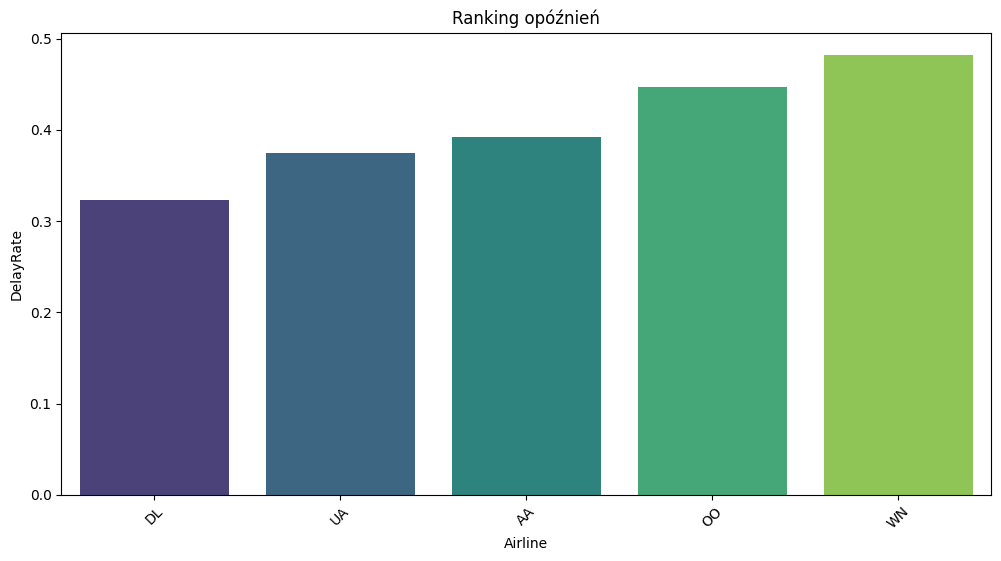

In [83]:
data_to_plot = delay_percentages.reset_index()
data_to_plot.columns = ['Airline', 'DelayRate']

plt.figure(figsize=(12, 6))
sns.barplot(x='Airline', y='DelayRate', data=data_to_plot, palette='viridis', hue='Airline')

plt.title('Ranking opóźnień')
plt.xticks(rotation=45)
plt.show()

# Analiza lotnisk